# Decomposed Emotion CAA Position-Mode Steering

This notebook runs a practical decomposition steering sweep for pooled emotion CAA vectors at layer 13. For each target emotion $e$, it separates the pooled CAA vector into:

- $g$: a shared emotionalization direction
- $\mathrm{resid}_e$: an emotion-specific residual direction

Steering uses unit-normalized directions so $\alpha_g$ and $\alpha_r$ are directly comparable:

$$
\Delta_e(\alpha_g, \alpha_r) = \alpha_g g + \alpha_r \, \widehat{\mathrm{resid}}_e
$$

The experiment generates only steered outputs. There is no `none` steering mode, and the alpha sweep should iterate directly over `ALPHA_PAIRS`, which excludes $(\alpha_g, \alpha_r) = (0, 0)$.

Position modes:

1. `last_token`: apply $\Delta$ to `hidden[:, -1:, :]` on every forward pass.
2. `completion_tokens`: with KV cache enabled, skip prompt prefill and apply $\Delta$ only when `hidden.shape[1] == 1`, which corresponds to single-token decode steps in the cached generation path.

Manual HTML inspection is primary. Proxy plots and optional LLM-judge batch preparation are secondary.

In [1]:
from __future__ import annotations

import csv
import gc
import html
import json
import sys
import warnings
from contextlib import contextmanager
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from IPython.display import HTML, display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

warnings.filterwarnings('ignore', category=UserWarning)

REPO_ROOT = Path('../..').resolve()
ACT_DIR = REPO_ROOT / 'activation' / 'emotion_rewrites'
CAA_PATH = ACT_DIR / 'caa_emotion_directions.npz'
CAA_INFO = ACT_DIR / 'caa_emotion_directions_info.json'
REWRITE_JSONL = REPO_ROOT / 'dataset' / 'emotion_rewrites' / 'emotion_rewrites.jsonl'

NOTEBOOK_NAME = 'caa_decomposed_position_mode_steering'
OUT_DIR = REPO_ROOT / 'analysis' / 'caa' / NOTEBOOK_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

GENERATIONS_JSONL = OUT_DIR / 'decomposed_position_mode_generations.jsonl'
GENERATIONS_CSV = OUT_DIR / 'decomposed_position_mode_generations.csv'
PROXY_SUMMARY_CSV = OUT_DIR / 'decomposed_position_mode_proxy_summary.csv'
JUDGE_REQUESTS_FILE = OUT_DIR / 'decomposed_position_mode_judge_requests.jsonl'
JUDGE_REQUEST_META_FILE = OUT_DIR / 'decomposed_position_mode_judge_request_meta.jsonl'

PRIMARY_LAYER = 13
MAX_EXAMPLES = 3
MAX_NEW_TOKENS = 100
DO_SAMPLE = False
USE_CACHE = True
SEED = 42
BATCH_SIZE = 4
CACHE_FLUSH_EVERY = 12

ALPHA_G_VALUES = [-5.0, -3.0, 3.0, 5.0]
ALPHA_R_VALUES = [-5.0, -3.0, -1.5, 1.5, 3.0, 5.0]
ALPHA_PAIRS = [
    (ag, ar)
    for ag in ALPHA_G_VALUES
    for ar in ALPHA_R_VALUES
    if not (ag == 0.0 and ar == 0.0)
]
# STEERING_MODES = ['last_token', 'completion_tokens']
STEERING_MODES = ['last_token', 'completion_tokens']

EXPECTED_EMOTION_ORDER = [
    'joy', 'trust', 'fear', 'surprise',
    'sadness', 'disgust', 'anger', 'anticipation',
]
OPPOSITE_EMOTION = {
    'joy': 'sadness',
    'trust': 'disgust',
    'fear': 'anger',
    'surprise': 'anticipation',
    'sadness': 'joy',
    'disgust': 'trust',
    'anger': 'fear',
    'anticipation': 'surprise',
}

EMOTIONS_TO_SHOW = None
MODES_TO_SHOW = None
ALPHA_G_TO_SHOW = [-5.0, -3.0, 3.0, 5.0]
ALPHA_R_TO_SHOW = [-5.0, -3.0, -1.5, 1.5, 3.0, 5.0]
MAX_SOURCES_PER_EMOTION = 1
PREPARE_JUDGE_BATCH = False
JUDGE_MODEL = 'gpt-4.1-mini'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))

from emotionengine.steering_utils import append_jsonl_csv_row, chunk_list, flush_device_cache, load_generation_df
from emotionengine.text_utils import extract_rewritten_text
from scripts.submit_openai_batch import summarize_jsonl

rng = np.random.default_rng(SEED)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

print(f'Repo root        : {REPO_ROOT}')
print(f'Output dir       : {OUT_DIR}')
print(f'Primary layer    : {PRIMARY_LAYER}')
print(f'MAX_EXAMPLES     : {MAX_EXAMPLES}')
print(f'alpha_g values   : {ALPHA_G_VALUES}')
print(f'alpha_r values   : {ALPHA_R_VALUES}')
print(f'alpha pairs      : {len(ALPHA_PAIRS)} steered combinations')
print(f'Steering modes   : {STEERING_MODES}')


/home/maplesugano/proj/EmotionEngine_v2/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root        : /home/maplesugano/proj/EmotionEngine_v2
Output dir       : /home/maplesugano/proj/EmotionEngine_v2/analysis/caa/caa_decomposed_position_mode_steering
Primary layer    : 13
MAX_EXAMPLES     : 3
alpha_g values   : [-5.0, -3.0, 3.0, 5.0]
alpha_r values   : [-5.0, -3.0, -1.5, 1.5, 3.0, 5.0]
alpha pairs      : 24 steered combinations
Steering modes   : ['last_token', 'completion_tokens']


In [2]:
def unit_np(vec: np.ndarray) -> np.ndarray:
    vec = np.asarray(vec, dtype=np.float32)
    return vec / (np.linalg.norm(vec) + 1e-12)

with open(CAA_INFO, encoding='utf-8') as f:
    caa_meta = json.load(f)

EMOTION_ORDER = list(caa_meta['emotion_order'])
LAYER_INDICES = list(caa_meta['layer_indices'])
assert EMOTION_ORDER == EXPECTED_EMOTION_ORDER, (EMOTION_ORDER, EXPECTED_EMOTION_ORDER)
assert PRIMARY_LAYER in LAYER_INDICES, f'Layer {PRIMARY_LAYER} missing from {LAYER_INDICES}'
LI = LAYER_INDICES.index(PRIMARY_LAYER)

caa_data = np.load(CAA_PATH)
caa_pooled = np.asarray(caa_data['caa_pooled'], dtype=np.float32)
C = np.stack([unit_np(vec) for vec in caa_pooled[:, LI, :]], axis=0)
D = int(C.shape[-1])

g_raw = C.mean(axis=0)
g = unit_np(g_raw)
proj = (C @ g)[:, None] * g[None, :]
resid_raw = C - proj
resid_raw_norm = np.linalg.norm(resid_raw, axis=1)
resid_unit = np.stack([unit_np(vec) for vec in resid_raw], axis=0)
EMOTION_TO_INDEX = {emotion: idx for idx, emotion in enumerate(EMOTION_ORDER)}

decomp_df = pd.DataFrame({
    'emotion': EMOTION_ORDER,
    'c_norm': np.linalg.norm(C, axis=1),
    'dot_with_g': C @ g,
    'resid_raw_norm': resid_raw_norm,
    'resid_unit_norm': np.linalg.norm(resid_unit, axis=1),
})

print(f'caa_pooled shape : {caa_pooled.shape}')
print(f'Layer indices    : {LAYER_INDICES} -> LI={LI}')
print(f'Hidden size      : {D}')
print(f'||g_raw||        : {np.linalg.norm(g_raw):.4f}')
print(f'||g||            : {np.linalg.norm(g):.4f}')
display(decomp_df)

caa_pooled shape : (8, 6, 4096)
Layer indices    : [8, 10, 13, 16, 19, 22] -> LI=2
Hidden size      : 4096
||g_raw||        : 0.9937
||g||            : 1.0000


,emotion,c_norm,dot_with_g,resid_raw_norm,resid_unit_norm
0,joy,1.0,0.992324,0.123664,1.0
1,trust,1.0,0.991750,0.128191,1.0
2,fear,1.0,0.994632,0.103481,1.0
3,surprise,1.0,0.990805,0.135296,1.0
4,sadness,1.0,0.996513,0.083442,1.0
5,disgust,1.0,0.995369,0.096128,1.0
6,anger,1.0,0.994058,0.108854,1.0
7,anticipation,1.0,0.994153,0.107979,1.0


In [3]:
records_raw: list[dict[str, Any]] = []
with open(REWRITE_JSONL, encoding='utf-8') as f:
    for line in f:
        records_raw.append(json.loads(line))

preferred_by_source: dict[str, dict[str, Any]] = {}
for rec in records_raw:
    sid = rec.get('source_id', '')
    if not sid or sid in preferred_by_source:
        continue
    if rec.get('source_split') == 'test' and rec.get('intensity_level') == 'medium':
        preferred_by_source[sid] = rec

if len(preferred_by_source) < MAX_EXAMPLES:
    fallback_by_source: dict[str, dict[str, Any]] = {}
    for rec in records_raw:
        sid = rec.get('source_id', '')
        if not sid or sid in fallback_by_source:
            continue
        if rec.get('source_split') == 'test':
            fallback_by_source[sid] = rec
    source_records = list(fallback_by_source.values())
else:
    source_records = list(preferred_by_source.values())

source_records = sorted(source_records, key=lambda rec: rec['source_id'])
sample_size = min(MAX_EXAMPLES, len(source_records))
sample_idx = rng.choice(len(source_records), size=sample_size, replace=False)
held_out = [source_records[i] for i in sorted(sample_idx)]

preview_df = pd.DataFrame([{
    'source_id': rec.get('source_id', ''),
    'source_split': rec.get('source_split', ''),
    'intensity_level': rec.get('intensity_level', ''),
    'base_text': rec.get('base_text', '')[:140],
} for rec in held_out])

print(f'Total JSONL rows    : {len(records_raw)}')
print(f'Candidate sources   : {len(source_records)}')
print(f'Held-out sample size: {len(held_out)}')
display(preview_df.head(10))

Total JSONL rows    : 68346
Candidate sources   : 376
Held-out sample size: 3


,source_id,source_split,intensity_level,base_text
0,dd_test_180_0,test,medium,"I'm very sorry , sir . My car has broken down ..."
1,dd_test_726_0,test,medium,"Hello , Tom . Where are you heading for ? I a..."
2,dd_test_822_0,test,medium,"Lee , I'm going to get married next month . G..."


## Steering Semantics

`last_token` and `completion_tokens` differ only in when the hook is allowed to apply the same decomposed steering delta.

- `last_token`: add the delta to `hidden[:, -1:, :]` on every forward pass, including prompt prefill and decode.
- `completion_tokens`: only add the delta when `hidden.shape[1] == 1`. With `use_cache=True`, prompt prefill usually has `seq_len > 1`, while cached decode steps process a single newly generated token and therefore have `seq_len == 1`. This is how the notebook distinguishes prefill from decode.
- The delta itself is always built from unit-normalized `g` and unit-normalized `resid_e` first, so `alpha_g` and `alpha_r` are directly comparable in magnitude.

In [4]:
from emotionengine.text_utils import make_instruction_prefix


with open(REPO_ROOT / 'model.yaml', encoding='utf-8') as f:
    model_cfg = yaml.safe_load(f)

MODEL_NAME = model_cfg['name']
DTYPE_MAP = {
    'bfloat16': torch.bfloat16,
    'float16': torch.float16,
    'float32': torch.float32,
}
MODEL_DTYPE = DTYPE_MAP.get(model_cfg.get('dtype', 'bfloat16'), torch.bfloat16)
ATTN_IMPL = model_cfg.get('attn_implementation', 'sdpa')
USE_4BIT = bool(model_cfg.get('load_in_4bit', False))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.padding_side = 'left'
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

bnb_cfg = None
if USE_4BIT:
    bnb_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

print(f'Loading model: {MODEL_NAME}')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=MODEL_DTYPE,
    attn_implementation=ATTN_IMPL,
    device_map='auto',
    low_cpu_mem_usage=True,
    quantization_config=bnb_cfg,
 )
model.eval()
MODEL_INPUT_DEVICE = next(model.parameters()).device
assert PRIMARY_LAYER < model.config.num_hidden_layers

hidden_norm_cache: dict[str, float] = {}

def build_delta_vector(target_emotion: str, alpha_g: float, alpha_r: float) -> np.ndarray:
    emotion_idx = EMOTION_TO_INDEX[target_emotion]
    delta_vec = float(alpha_g) * g + float(alpha_r) * resid_unit[emotion_idx]
    return np.asarray(delta_vec, dtype=np.float32)

def get_prompt_hidden_norm(base_text: str) -> float:
    key = base_text.strip()
    if key in hidden_norm_cache:
        return hidden_norm_cache[key]

    prompt = make_instruction_prefix(base_text, tokenizer)
    inputs = tokenizer(prompt, return_tensors='pt').to(MODEL_INPUT_DEVICE)
    layer_module = model.model.layers[PRIMARY_LAYER]
    layer_device = next(layer_module.parameters()).device
    stats: dict[str, float] = {}

    def _probe_hook(_module: Any, _args: Any, output: Any) -> Any:
        hidden = output[0] if isinstance(output, tuple) else output
        last_hidden = hidden[:, -1, :].detach().to(layer_device)
        stats['hidden_norm'] = float(last_hidden.norm(dim=-1).mean().item())
        return output

    handle = layer_module.register_forward_hook(_probe_hook)
    try:
        with torch.inference_mode():
            model(**inputs, use_cache=False)
    finally:
        handle.remove()
        del inputs

    hidden_norm_cache[key] = stats.get('hidden_norm', float('nan'))
    return hidden_norm_cache[key]

def build_scale_stats(base_text: str, target_emotion: str, alpha_g: float, alpha_r: float) -> dict[str, float]:
    delta_vec = build_delta_vector(target_emotion, alpha_g, alpha_r)
    delta_norm = float(np.linalg.norm(delta_vec))
    hidden_norm = get_prompt_hidden_norm(base_text)
    delta_over_hidden = delta_norm / max(hidden_norm, 1e-8) if np.isfinite(hidden_norm) else float('nan')
    return {
        'delta_norm': delta_norm,
        'hidden_norm': hidden_norm,
        'delta_over_hidden': delta_over_hidden,
    }

@contextmanager
def steering_hook(
    steer_model: AutoModelForCausalLM,
    layer_idx: int,
    delta_vec: np.ndarray,
    steering_mode: str,
    hook_stats: dict[str, int],
):
    if steering_mode not in STEERING_MODES:
        raise ValueError(f'Unknown steering_mode: {steering_mode}')

    layer_module = steer_model.model.layers[layer_idx]
    layer_device = next(layer_module.parameters()).device
    layer_dtype = next(layer_module.parameters()).dtype
    delta = torch.as_tensor(delta_vec, dtype=layer_dtype, device=layer_device).view(1, 1, -1)

    def _hook(_module: Any, _args: Any, output: Any) -> Any:
        hidden = output[0] if isinstance(output, tuple) else output
        rest = output[1:] if isinstance(output, tuple) else None

        seq_len = int(hidden.shape[1])
        is_decode_step = seq_len == 1
        hook_stats['hook_calls'] += 1
        hook_stats['hook_prefill_calls'] += int(not is_decode_step)
        hook_stats['hook_decode_calls'] += int(is_decode_step)

        should_apply = steering_mode == 'last_token' or (
            steering_mode == 'completion_tokens' and is_decode_step
        )
        if not should_apply:
            return output

        steered_hidden = hidden.clone()
        steered_hidden[:, -1:, :] = steered_hidden[:, -1:, :] + delta
        hook_stats['hook_applied_calls'] += 1
        return (steered_hidden, *rest) if rest is not None else steered_hidden

    handle = layer_module.register_forward_hook(_hook)
    try:
        yield
    finally:
        handle.remove()
        del delta

def generate_rewrite_batch_decomposed(
    base_texts: list[str],
    target_emotion: str,
    alpha_g: float,
    alpha_r: float,
    steering_mode: str,
    layer_idx: int = PRIMARY_LAYER,
) -> list[dict[str, Any]]:
    prompts = [make_instruction_prefix(base_text, tokenizer) for base_text in base_texts]
    inputs = tokenizer(
        prompts,
        return_tensors='pt',
        padding=True,
        truncation=True,
    ).to(MODEL_INPUT_DEVICE)
    prompt_width = inputs['input_ids'].shape[1]

    hook_stats = {
        'hook_calls': 0,
        'hook_prefill_calls': 0,
        'hook_decode_calls': 0,
        'hook_applied_calls': 0,
    }
    delta_vec = build_delta_vector(target_emotion, alpha_g, alpha_r)

    gen_kwargs = {
        'max_new_tokens': MAX_NEW_TOKENS,
        'do_sample': DO_SAMPLE,
        'use_cache': USE_CACHE,
        'pad_token_id': tokenizer.pad_token_id,
    }

    try:
        with torch.inference_mode():
            with steering_hook(model, layer_idx, delta_vec, steering_mode, hook_stats):
                out_ids = model.generate(**inputs, **gen_kwargs)

        batch_results: list[dict[str, Any]] = []
        for row_idx in range(len(base_texts)):
            new_ids = out_ids[row_idx, prompt_width:]
            generated_text = tokenizer.decode(
                new_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            ).strip()
            generated_text = extract_rewritten_text(generated_text)
            batch_results.append({
                'generated_text': generated_text,
                **hook_stats,
            })
    except torch.cuda.OutOfMemoryError:
        flush_device_cache()
        batch_results = [
            {'generated_text': '[OOM]', **hook_stats}
            for _ in base_texts
        ]
    finally:
        del inputs
        if 'out_ids' in locals():
            del out_ids

    return batch_results

def generation_key(
    source_id: str,
    target_emotion: str,
    steering_mode: str,
    alpha_g: float,
    alpha_r: float,
    layer: int,
) -> tuple[str, str, str, float, float, int]:
    return (
        source_id,
        target_emotion,
        steering_mode,
        float(alpha_g),
        float(alpha_r),
        int(layer),
    )

GENERATION_FIELDNAMES = [
    'source_id',
    'base_text',
    'target_emotion',
    'opposite_emotion',
    'layer',
    'steering_mode',
    'alpha_g',
    'alpha_r',
    'generated_text',
    'delta_norm',
    'hidden_norm',
    'delta_over_hidden',
    'hook_calls',
    'hook_prefill_calls',
    'hook_decode_calls',
    'hook_applied_calls',
]

print(f'Model dtype     : {MODEL_DTYPE}')
print(f'Attention impl  : {ATTN_IMPL}')
print(f'4-bit quantized : {USE_4BIT}')
print(f'Input device    : {MODEL_INPUT_DEVICE}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading model: meta-llama/Llama-3.1-8B-Instruct


Loading weights: 100%|██████████| 291/291 [00:02<00:00, 118.05it/s]


Model dtype     : torch.bfloat16
Attention impl  : sdpa
4-bit quantized : False
Input device    : cuda:0


In [5]:
smoke_record = held_out[0]
smoke_emotion = EMOTION_ORDER[0]
smoke_alpha_g = 1.5
smoke_alpha_r = 1.0

smoke_rows = []
for mode in STEERING_MODES:
    result = generate_rewrite_batch_decomposed(
        [smoke_record['base_text']],
        target_emotion=smoke_emotion,
        alpha_g=smoke_alpha_g,
        alpha_r=smoke_alpha_r,
        steering_mode=mode,
    )[0]
    smoke_rows.append({
        'mode': mode,
        'delta_norm': build_scale_stats(smoke_record['base_text'], smoke_emotion, smoke_alpha_g, smoke_alpha_r)['delta_norm'],
        'hook_calls': result['hook_calls'],
        'hook_prefill_calls': result['hook_prefill_calls'],
        'hook_decode_calls': result['hook_decode_calls'],
        'hook_applied_calls': result['hook_applied_calls'],
        'generated_text': result['generated_text'],
    })

smoke_df = pd.DataFrame(smoke_rows)
display(smoke_df[['mode', 'delta_norm', 'hook_calls', 'hook_prefill_calls', 'hook_decode_calls', 'hook_applied_calls']])
display(smoke_df[['mode', 'generated_text']])

,mode,delta_norm,hook_calls,hook_prefill_calls,hook_decode_calls,hook_applied_calls
0,last_token,1.802777,68,1,67,68
1,completion_tokens,1.802777,68,1,67,67


,mode,generated_text
0,last_token,"I'm really sorry to be a bother, but my car ha..."
1,completion_tokens,"I'm really sorry to be a bother, but my car ha..."


## Full Sweep

This cell runs the resumable decomposed steering sweep. It iterates over `ALPHA_PAIRS` directly, so every generated row is a steered condition and `(0, 0)` is excluded.

In [6]:
existing_df = load_generation_df(GENERATIONS_JSONL)
existing_keys: set[tuple[str, str, str, float, float, int]] = set()
if existing_df is not None and not existing_df.empty:
    for row in existing_df.to_dict(orient='records'):
        existing_keys.add(
            generation_key(
                str(row['source_id']),
                str(row['target_emotion']),
                str(row['steering_mode']),
                float(row['alpha_g']),
                float(row['alpha_r']),
                int(row['layer']),
            )
        )

total_conditions = len(held_out) * len(EMOTION_ORDER) * len(STEERING_MODES) * len(ALPHA_PAIRS)
pending_conditions = total_conditions - len(existing_keys)
print(f'Cached rows        : {len(existing_keys)}')
print(f'Total conditions   : {total_conditions}')
print(f'Pending conditions : {pending_conditions}')

rows_written = 0
batch_counter = 0

for target_emotion in EMOTION_ORDER:
    for steering_mode in STEERING_MODES:
        for alpha_g, alpha_r in tqdm(ALPHA_PAIRS, desc=f'{target_emotion}:{steering_mode}', leave=False):
            pending_records = [
                rec for rec in held_out
                if generation_key(
                    rec['source_id'],
                    target_emotion,
                    steering_mode,
                    alpha_g,
                    alpha_r,
                    PRIMARY_LAYER,
                ) not in existing_keys
            ]
            if not pending_records:
                continue

            for record_batch in chunk_list(pending_records, BATCH_SIZE):
                base_texts = [rec['base_text'] for rec in record_batch]
                batch_results = generate_rewrite_batch_decomposed(
                    base_texts=base_texts,
                    target_emotion=target_emotion,
                    alpha_g=alpha_g,
                    alpha_r=alpha_r,
                    steering_mode=steering_mode,
                    layer_idx=PRIMARY_LAYER,
                )

                for rec, result in zip(record_batch, batch_results):
                    scale_stats = build_scale_stats(
                        rec['base_text'],
                        target_emotion,
                        alpha_g,
                        alpha_r,
                    )
                    row = {
                        'source_id': rec['source_id'],
                        'base_text': rec['base_text'],
                        'target_emotion': target_emotion,
                        'opposite_emotion': OPPOSITE_EMOTION[target_emotion],
                        'layer': PRIMARY_LAYER,
                        'steering_mode': steering_mode,
                        'alpha_g': float(alpha_g),
                        'alpha_r': float(alpha_r),
                        'generated_text': result['generated_text'],
                        'delta_norm': scale_stats['delta_norm'],
                        'hidden_norm': scale_stats['hidden_norm'],
                        'delta_over_hidden': scale_stats['delta_over_hidden'],
                        'hook_calls': int(result['hook_calls']),
                        'hook_prefill_calls': int(result['hook_prefill_calls']),
                        'hook_decode_calls': int(result['hook_decode_calls']),
                        'hook_applied_calls': int(result['hook_applied_calls']),
                    }
                    append_jsonl_csv_row(
                        GENERATIONS_JSONL,
                        GENERATIONS_CSV,
                        GENERATION_FIELDNAMES,
                        row,
                    )
                    existing_keys.add(
                        generation_key(
                            rec['source_id'],
                            target_emotion,
                            steering_mode,
                            alpha_g,
                            alpha_r,
                            PRIMARY_LAYER,
                        )
                    )
                    rows_written += 1

                batch_counter += 1
                if batch_counter % CACHE_FLUSH_EVERY == 0:
                    flush_device_cache()

flush_device_cache()
gen_df = load_generation_df(GENERATIONS_JSONL)
print(f'New rows written   : {rows_written}')
print(f'Total cached rows  : {0 if gen_df is None else len(gen_df)}')
display(gen_df.head(10) if gen_df is not None else pd.DataFrame())

Cached rows        : 1152
Total conditions   : 1152
Pending conditions : 0


New rows written   : 0
Total cached rows  : 1152


,source_id,base_text,target_emotion,opposite_emotion,layer,steering_mode,alpha_g,alpha_r,generated_text,delta_norm,hidden_norm,delta_over_hidden,hook_calls,hook_prefill_calls,hook_decode_calls,hook_applied_calls
0,dd_test_180_0,"I'm very sorry , sir . My car has broken down ...",joy,sadness,13,last_token,-5,-5.0,"I'm extremely sorry, sir, my car has broken do...",7.071073,7.1875,0.983801,100,1,99,100
1,dd_test_726_0,"Hello , Tom . Where are you heading for ? I a...",joy,sadness,13,last_token,-5,-5.0,"I'm not a fan of excessive violence in movies,...",7.071073,7.2500,0.975320,100,1,99,100
2,dd_test_822_0,"Lee , I'm going to get married next month . G...",joy,sadness,13,last_token,-5,-5.0,You're getting married? I'm still trying to pr...,7.071073,7.1250,0.992431,100,1,99,100
3,dd_test_180_0,"I'm very sorry , sir . My car has broken down ...",joy,sadness,13,last_token,-5,-3.0,"I'm extremely sorry, sir, that my car has brok...",5.830955,7.1875,0.811263,100,1,99,100
4,dd_test_726_0,"Hello , Tom . Where are you heading for ? I a...",joy,sadness,13,last_token,-5,-3.0,I'm not a fan of the excessive violence in mov...,5.830955,7.2500,0.804270,100,1,99,100
5,dd_test_822_0,"Lee , I'm going to get married next month . G...",joy,sadness,13,last_token,-5,-3.0,You're the first person I think of when I thin...,5.830955,7.1250,0.818380,100,1,99,100
6,dd_test_180_0,"I'm very sorry , sir . My car has broken down ...",joy,sadness,13,last_token,-5,-1.5,"I'm truly sorry to do this, but my car has bro...",5.220155,7.1875,0.726282,100,1,99,100
7,dd_test_726_0,"Hello , Tom . Where are you heading for ? I a...",joy,sadness,13,last_token,-5,-1.5,"I'm not a fan of cliché Hollywood productions,...",5.220155,7.2500,0.720021,100,1,99,100
8,dd_test_822_0,"Lee , I'm going to get married next month . G...",joy,sadness,13,last_token,-5,-1.5,"Lee, I have some life-changing news to share w...",5.220155,7.1250,0.732653,100,1,99,100
9,dd_test_180_0,"I'm very sorry , sir . My car has broken down ...",joy,sadness,13,last_token,-5,1.5,"I'm really sorry to be a bother, but my car ha...",5.220151,7.1875,0.726282,100,1,99,100


## Proxy Analysis

These plots are secondary to manual inspection. They summarize simple automatic proxies over the cached sweep for each emotion, steering mode, and `alpha_g × alpha_r` pair.

,target_emotion,steering_mode,alpha_g,alpha_r,n_rows,mean_text_length_chars,mean_text_length_words,mean_repetition_rate
0,anger,completion_tokens,-5.0,-5.0,3,358.000000,71.000000,0.261822
1,anger,completion_tokens,-5.0,-3.0,3,424.333333,75.666667,0.212705
2,anger,completion_tokens,-5.0,-1.5,3,329.666667,65.333333,0.204380
3,anger,completion_tokens,-5.0,1.5,3,348.666667,67.000000,0.209570
4,anger,completion_tokens,-5.0,3.0,3,413.000000,73.666667,0.211167
5,anger,completion_tokens,-5.0,5.0,3,393.333333,76.333333,0.384775
6,anger,completion_tokens,-3.0,-5.0,3,398.000000,70.666667,0.206578
7,anger,completion_tokens,-3.0,-3.0,3,371.000000,70.333333,0.211081
8,anger,completion_tokens,-3.0,-1.5,3,368.000000,68.666667,0.209746
9,anger,completion_tokens,-3.0,1.5,3,386.666667,74.000000,0.231313


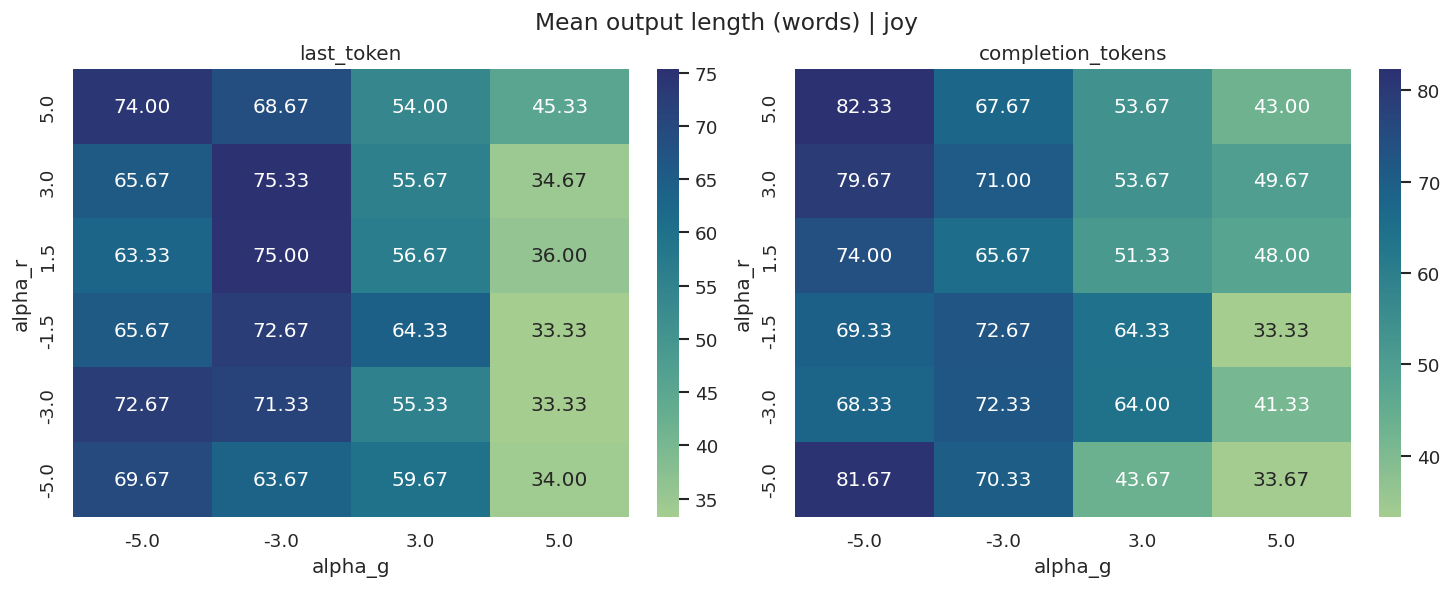

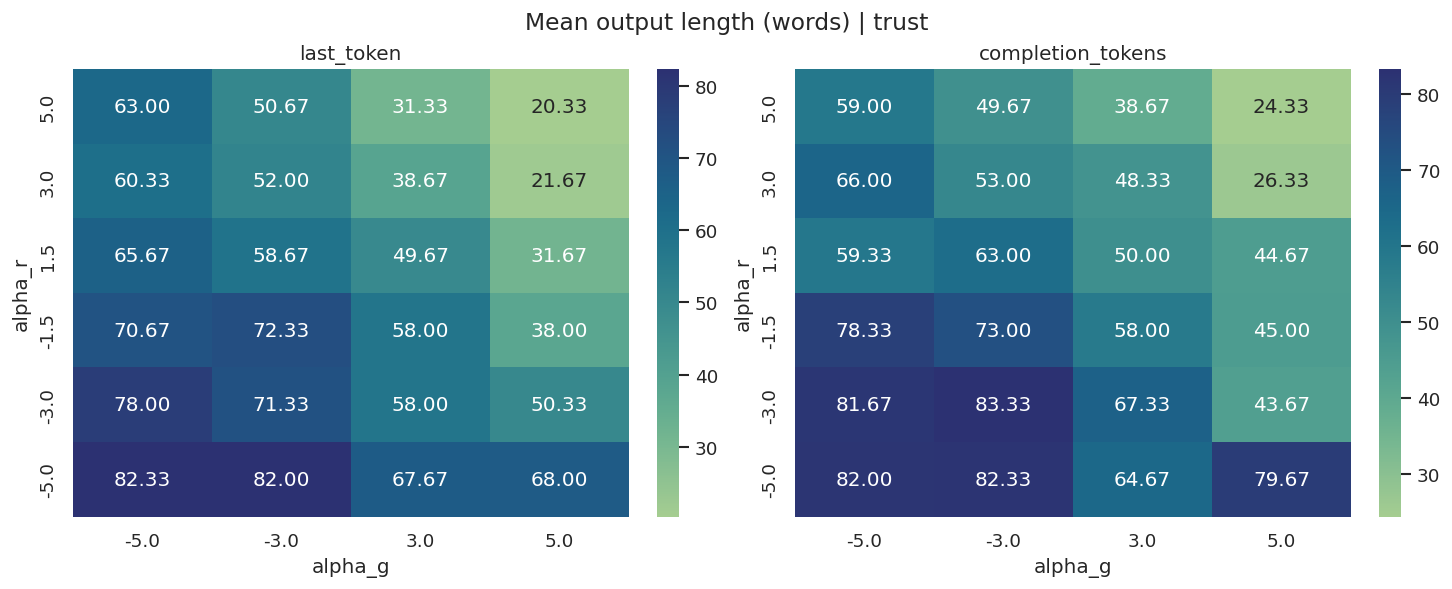

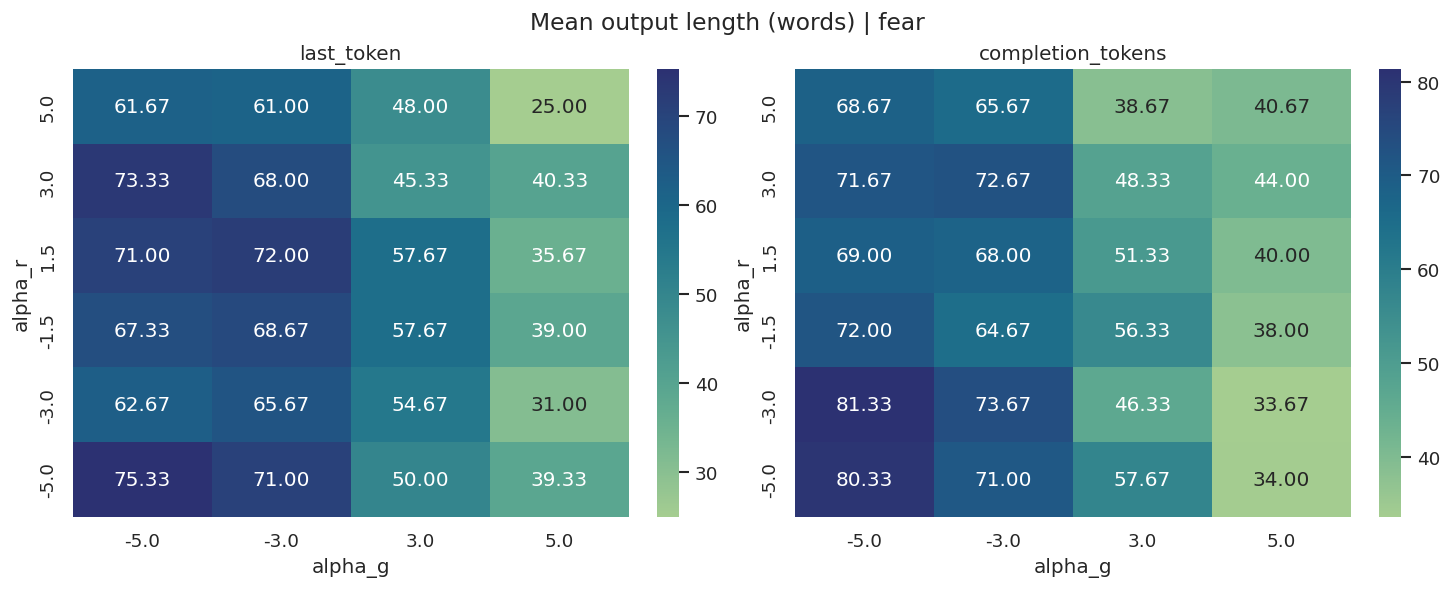

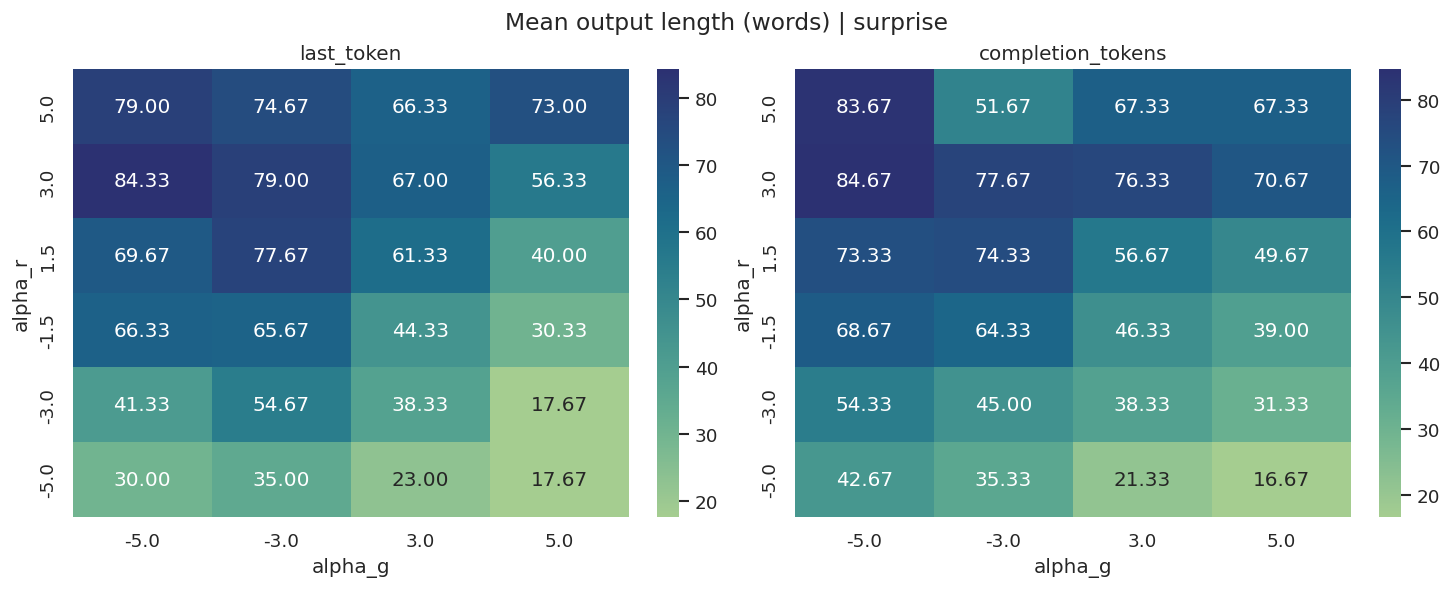

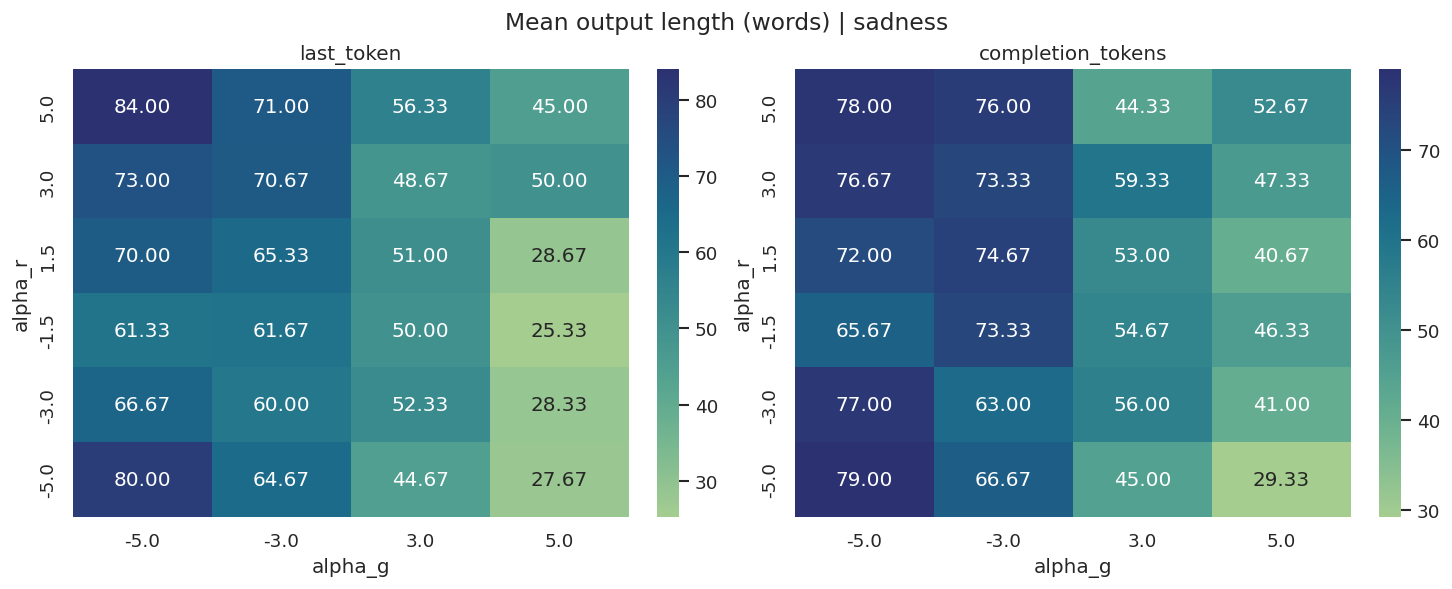

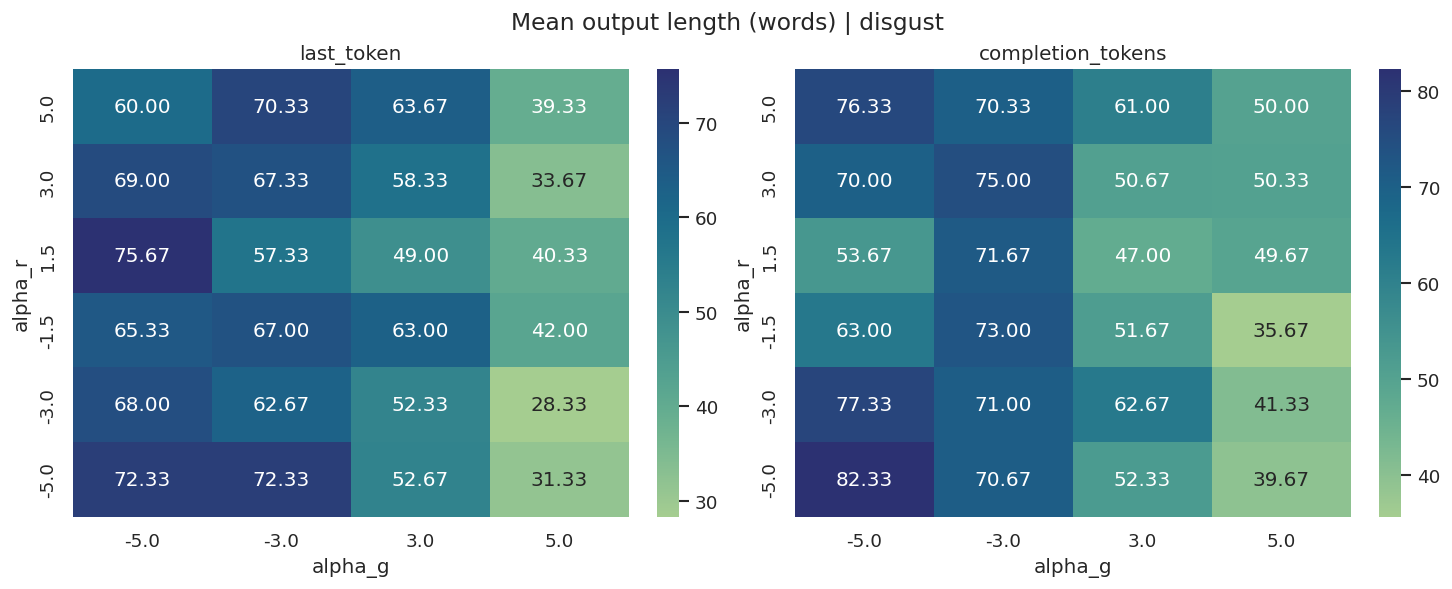

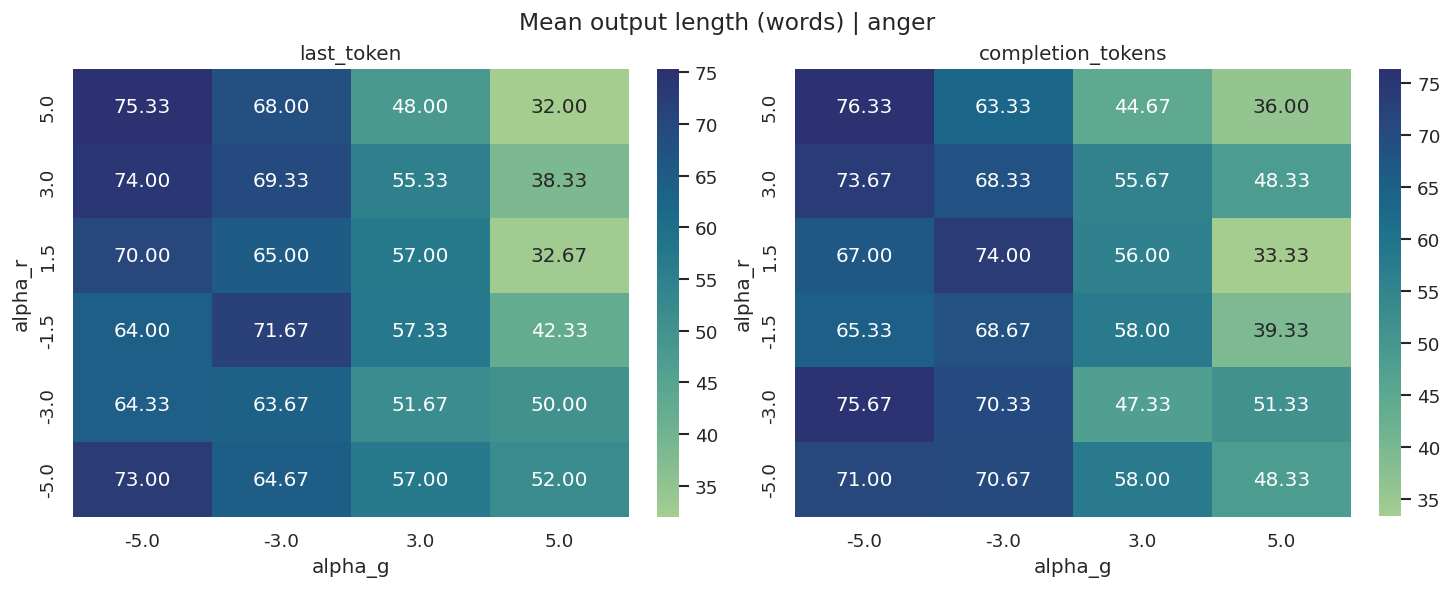

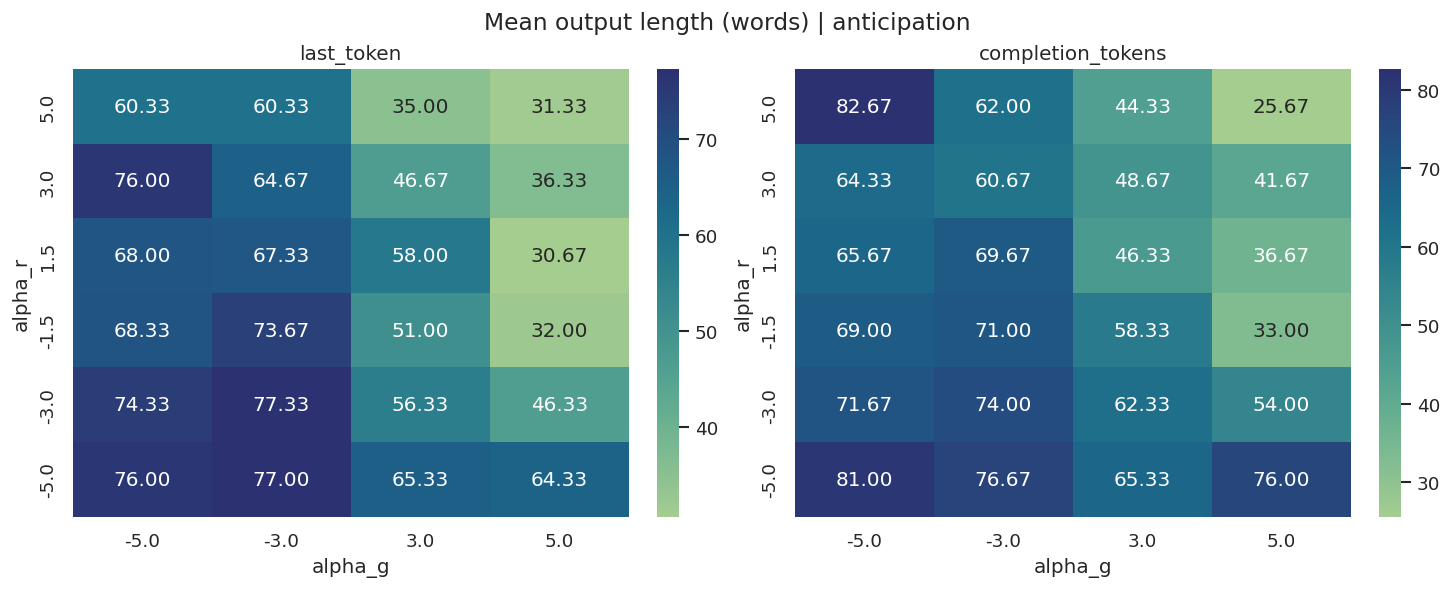

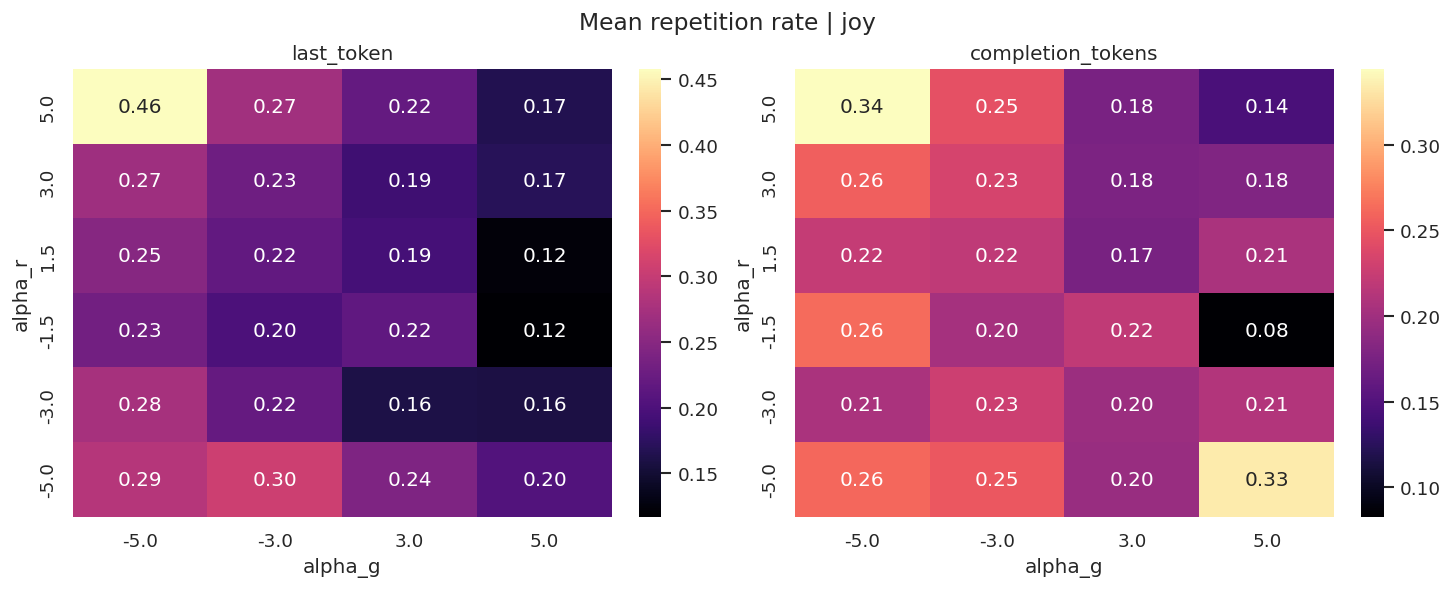

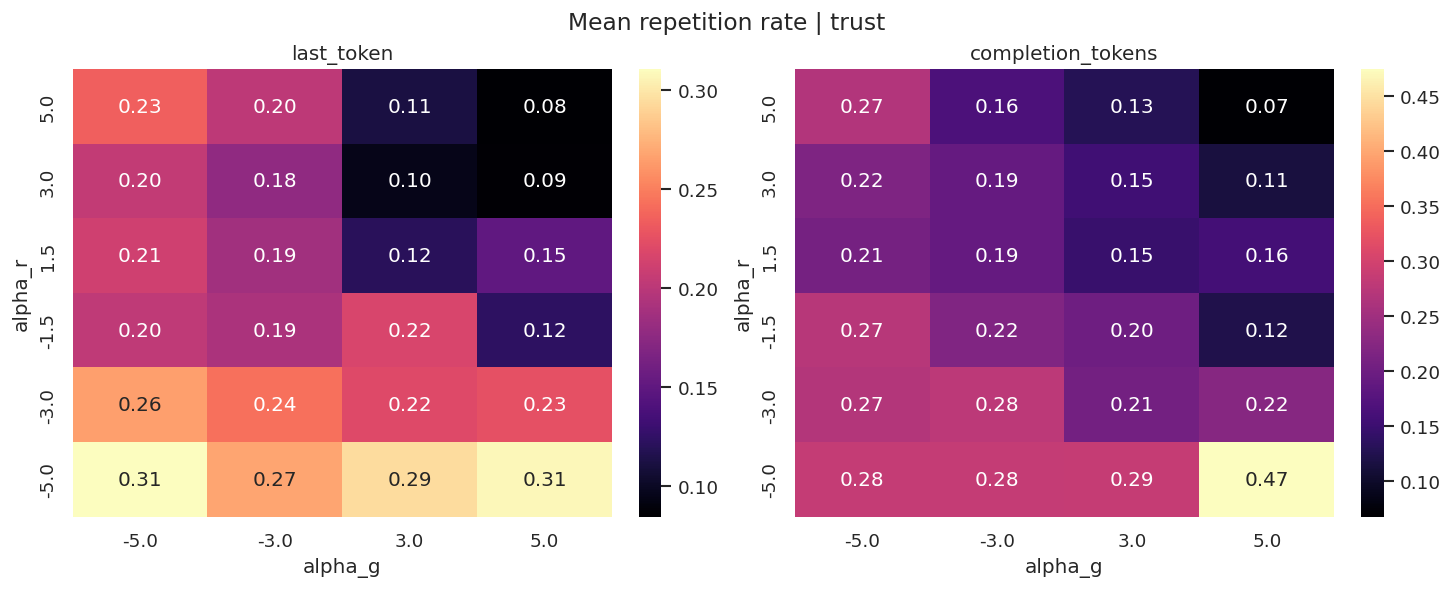

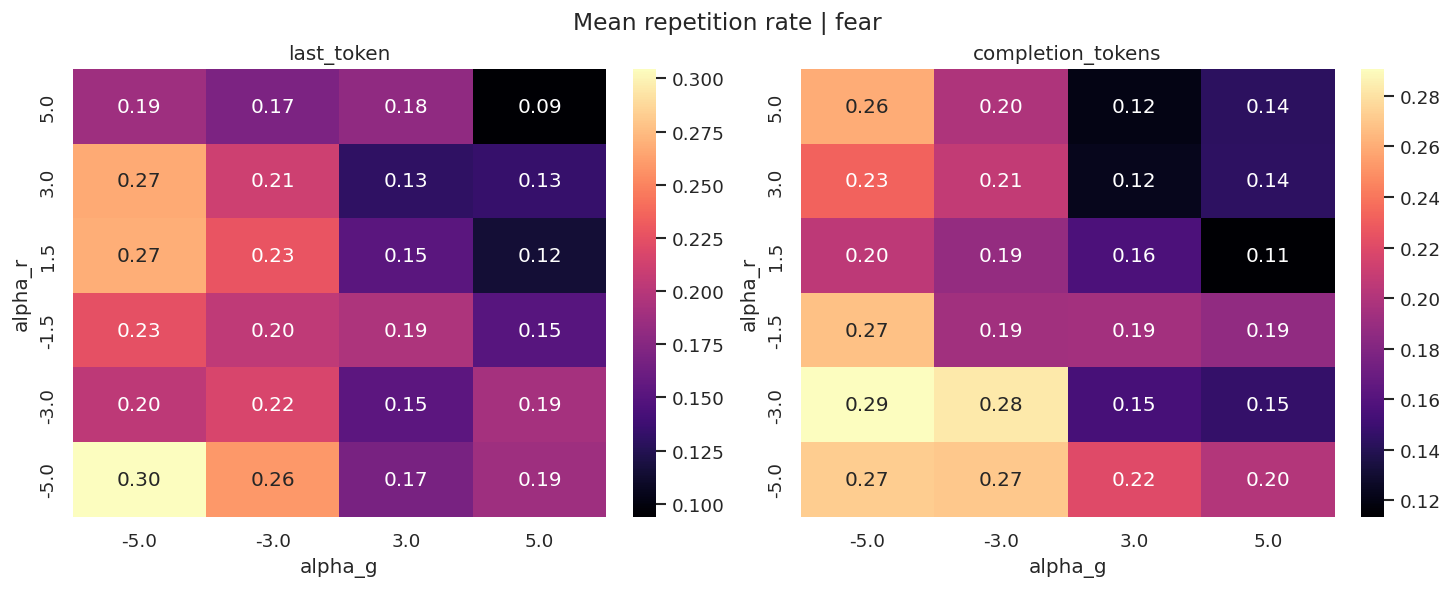

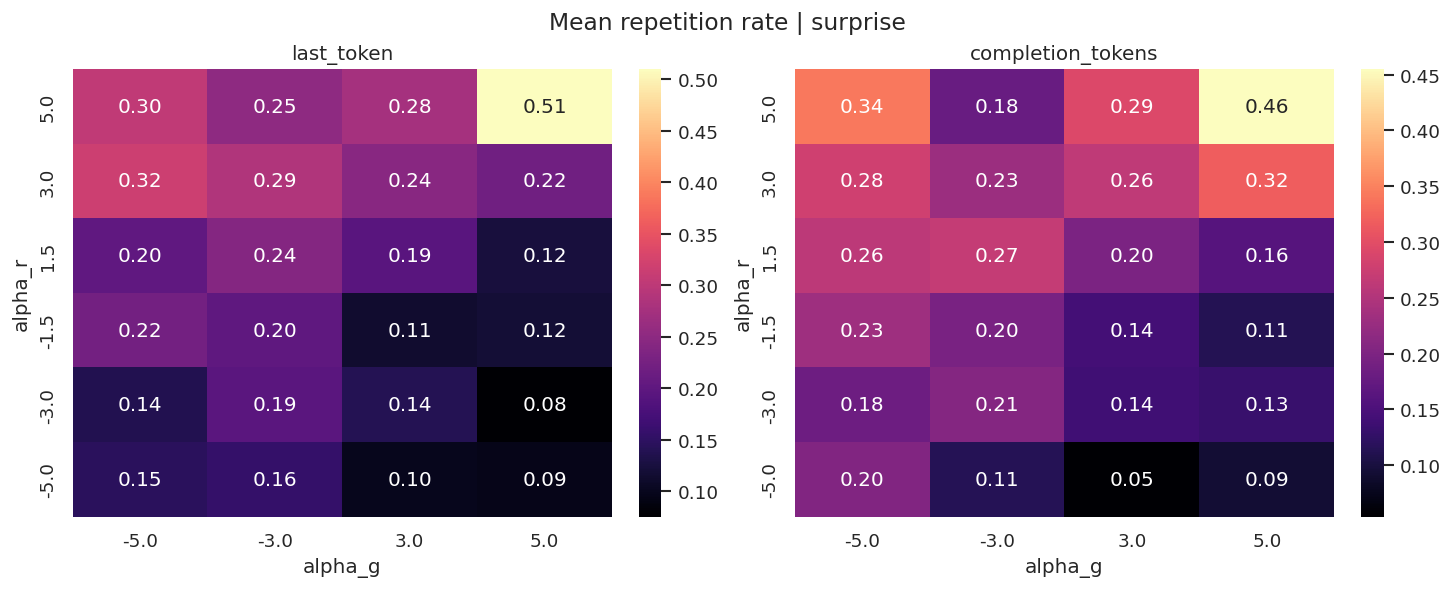

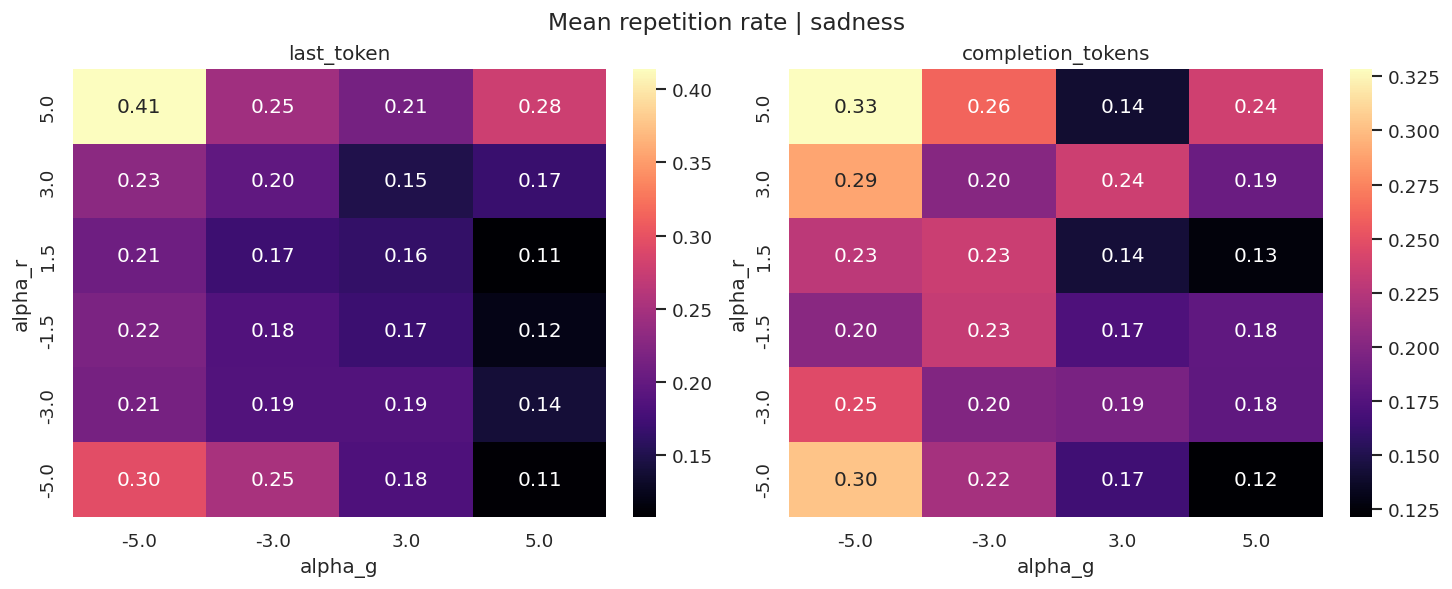

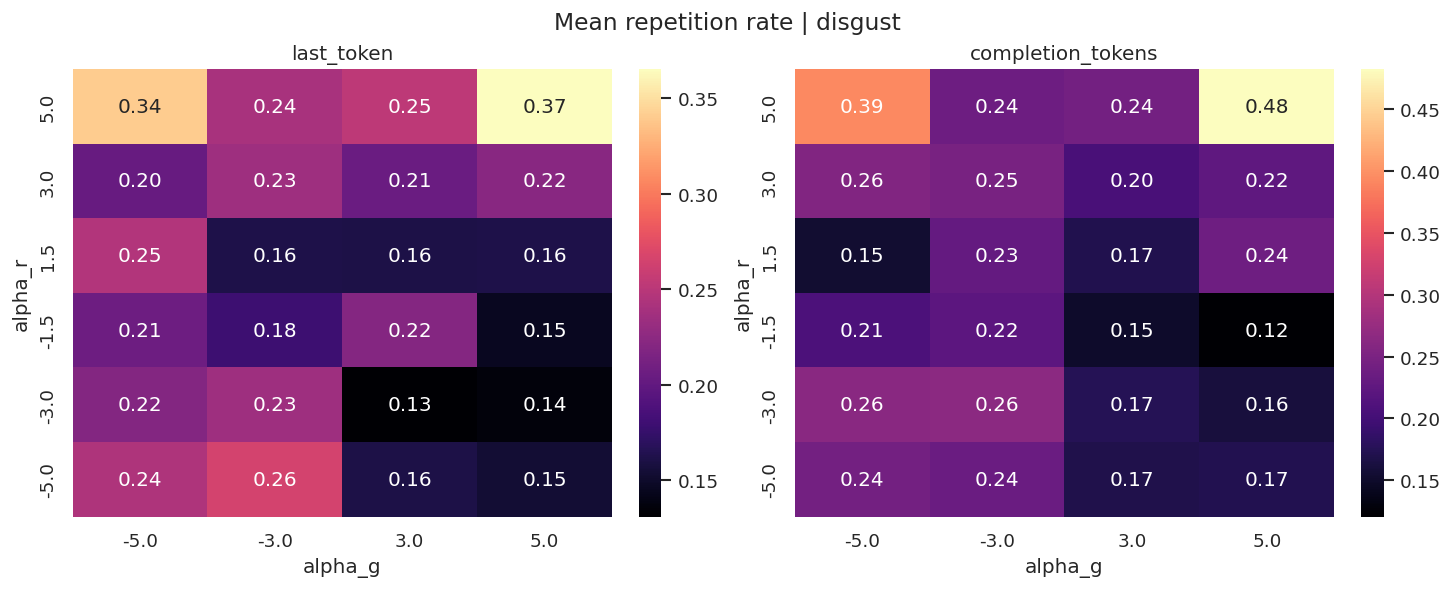

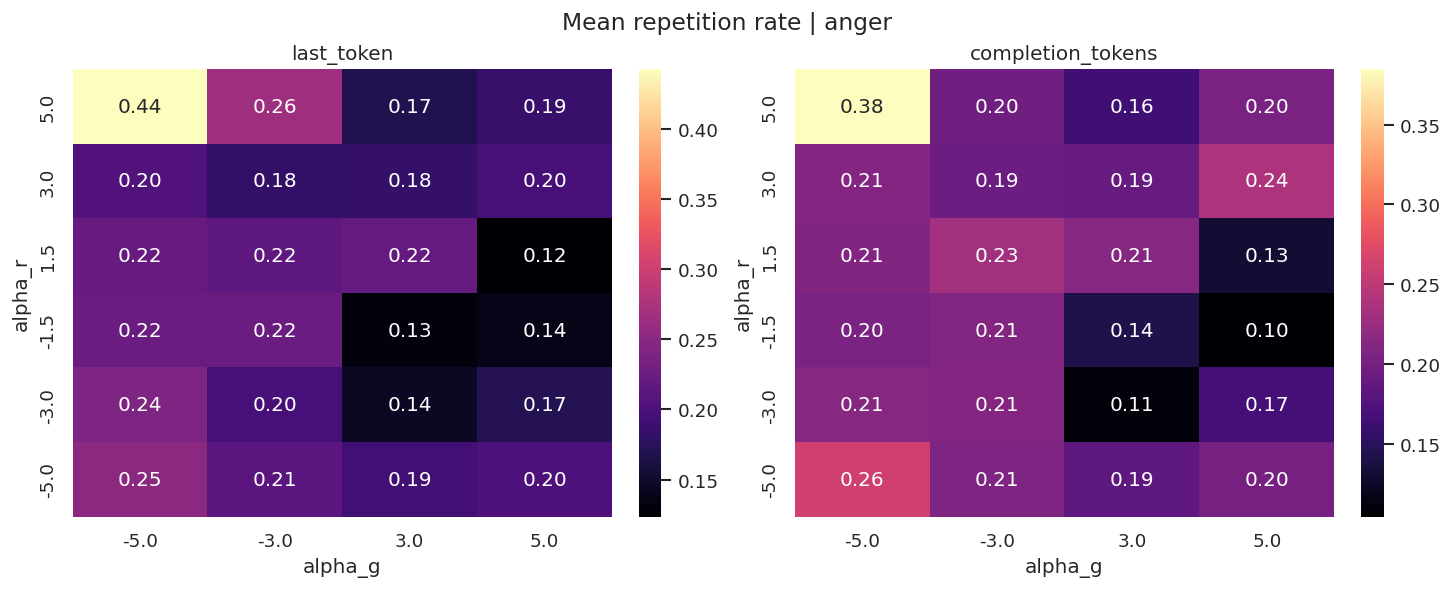

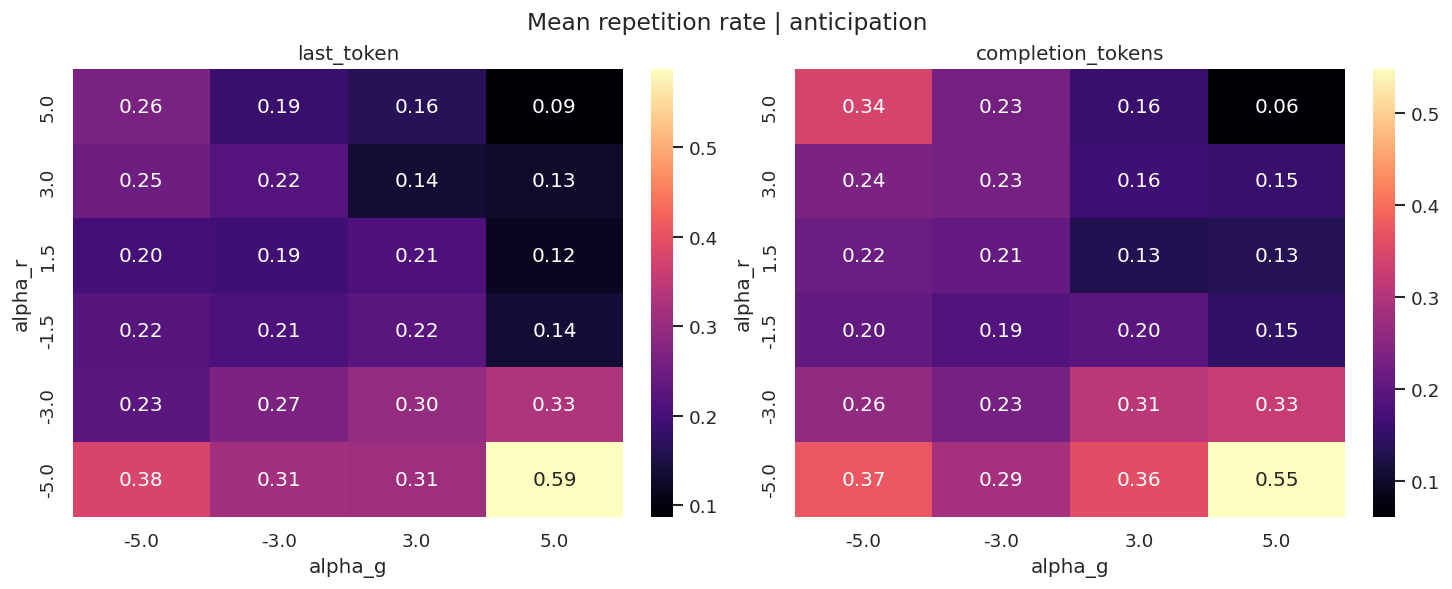

In [7]:
gen_df = load_generation_df(GENERATIONS_JSONL)
if gen_df is None or gen_df.empty:
    raise FileNotFoundError(
        f'No generation cache found at {GENERATIONS_JSONL}. Run the sweep cell first.'
    )

def repetition_rate(text: str) -> float:
    tokens = [tok for tok in str(text).split() if tok]
    if len(tokens) < 2:
        return 0.0
    return 1.0 - (len(set(tokens)) / len(tokens))

proxy_df = gen_df.copy()
proxy_df['generated_text'] = proxy_df['generated_text'].fillna('')
proxy_df['alpha_g'] = pd.to_numeric(proxy_df['alpha_g'], errors='coerce')
proxy_df['alpha_r'] = pd.to_numeric(proxy_df['alpha_r'], errors='coerce')
proxy_df['text_length_chars'] = proxy_df['generated_text'].str.len()
proxy_df['text_length_words'] = proxy_df['generated_text'].str.split().str.len()
proxy_df['repetition_rate'] = proxy_df['generated_text'].map(repetition_rate)
proxy_df['is_empty'] = proxy_df['generated_text'].str.strip().eq('')
proxy_df['is_oom'] = proxy_df['generated_text'].str.strip().eq('[OOM]')

summary_rows: list[dict[str, Any]] = []
for keys, group in proxy_df.groupby(['target_emotion', 'steering_mode', 'alpha_g', 'alpha_r'], dropna=False):
    target_emotion, steering_mode, alpha_g, alpha_r = keys
    normalized = group['generated_text'].str.strip()
    summary_rows.append({
        'target_emotion': target_emotion,
        'steering_mode': steering_mode,
        'alpha_g': float(alpha_g),
        'alpha_r': float(alpha_r),
        'n_rows': int(len(group)),
        'mean_text_length_chars': float(group['text_length_chars'].mean()),
        'mean_text_length_words': float(group['text_length_words'].mean()),
        'mean_repetition_rate': float(group['repetition_rate'].mean()),
    })

proxy_summary_df = pd.DataFrame(summary_rows).sort_values(
    ['target_emotion', 'steering_mode', 'alpha_g', 'alpha_r']
 )
proxy_summary_df.to_csv(PROXY_SUMMARY_CSV, index=False)
display(proxy_summary_df.head(12))

plot_metrics = [
    ('mean_text_length_words', 'Mean output length (words)', 'crest'),
    ('mean_repetition_rate', 'Mean repetition rate', 'magma'),
]

plot_emotions = EMOTIONS_TO_SHOW if EMOTIONS_TO_SHOW else EMOTION_ORDER
for metric_name, title, cmap in plot_metrics:
    for target_emotion in plot_emotions:
        fig, axes = plt.subplots(
            1,
            len(STEERING_MODES),
            figsize=(6 * len(STEERING_MODES), 4.8),
            constrained_layout=True,
        )
        if len(STEERING_MODES) == 1:
            axes = [axes]

        fig.suptitle(f'{title} | {target_emotion}', fontsize=14)
        for ax, steering_mode in zip(axes, STEERING_MODES):
            subset = proxy_summary_df[
                (proxy_summary_df['target_emotion'] == target_emotion)
                & (proxy_summary_df['steering_mode'] == steering_mode)
            ]
            if subset.empty:
                ax.set_axis_off()
                ax.set_title(f'{steering_mode}\n(no rows)')
                continue

            pivot = subset.pivot(index='alpha_r', columns='alpha_g', values=metric_name)
            pivot = pivot.sort_index(ascending=False)
            sns.heatmap(
                pivot,
                ax=ax,
                cmap=cmap,
                annot=True,
                fmt='.2f',
                cbar=True,
            )
            ax.set_title(steering_mode)
            ax.set_xlabel('alpha_g')
            ax.set_ylabel('alpha_r')
        plt.show()

## Manual Inspection And Optional Judge Export

This cell renders dark-mode HTML grouped by emotion, source text, steering mode, `alpha_g`, and `alpha_r`. It never shows a `none` row. If `PREPARE_JUDGE_BATCH = True`, it also writes a lightweight OpenAI batch request file for optional offline judging.

In [8]:
gen_df = load_generation_df(GENERATIONS_JSONL)
if gen_df is None or gen_df.empty:
    raise FileNotFoundError(
        f'No generation cache found at {GENERATIONS_JSONL}. Run the sweep cell first.'
    )

display_df = gen_df.copy()
display_df = display_df[display_df['steering_mode'].isin(STEERING_MODES)].copy()
display_df['alpha_g'] = pd.to_numeric(display_df['alpha_g'], errors='coerce')
display_df['alpha_r'] = pd.to_numeric(display_df['alpha_r'], errors='coerce')
display_df['layer'] = pd.to_numeric(display_df['layer'], errors='coerce')

if EMOTIONS_TO_SHOW:
    display_df = display_df[display_df['target_emotion'].isin(EMOTIONS_TO_SHOW)]
if MODES_TO_SHOW:
    display_df = display_df[display_df['steering_mode'].isin(MODES_TO_SHOW)]
if ALPHA_G_TO_SHOW is not None:
    display_df = display_df[display_df['alpha_g'].isin(ALPHA_G_TO_SHOW)]
if ALPHA_R_TO_SHOW is not None:
    display_df = display_df[display_df['alpha_r'].isin(ALPHA_R_TO_SHOW)]

display_df = display_df.sort_values(
    ['target_emotion', 'source_id', 'base_text', 'steering_mode', 'alpha_g', 'alpha_r']
).reset_index(drop=True)

if MAX_SOURCES_PER_EMOTION is not None:
    kept_frames = []
    for target_emotion in EMOTION_ORDER:
        subset = display_df[display_df['target_emotion'] == target_emotion]
        if subset.empty:
            continue
        keep_ids = subset['source_id'].drop_duplicates().tolist()[:MAX_SOURCES_PER_EMOTION]
        kept_frames.append(subset[subset['source_id'].isin(keep_ids)])
    display_df = pd.concat(kept_frames, ignore_index=True) if kept_frames else display_df.iloc[0:0]

def esc(value: Any) -> str:
    if pd.isna(value):
        return ''
    return html.escape(str(value))

def fmt_value(value: Any, digits: int = 2) -> str:
    if pd.isna(value):
        return 'NA'
    try:
        return f'{float(value):.{digits}f}'
    except Exception:
        return esc(value)

parts = [
    '''<style>
    .decomp-root {
        background: radial-gradient(circle at top, #1d2638 0%, #0d1117 58%, #05070a 100%);
        color: #e6edf3;
        padding: 20px;
        font-family: 'Iosevka', 'IBM Plex Sans', 'Segoe UI', sans-serif;
    }
    .decomp-root h2, .decomp-root h3, .decomp-root h4 { margin: 0; }
    .emotion-block { margin: 0 0 28px 0; padding: 20px; border: 1px solid #273449; border-radius: 18px; background: rgba(13, 17, 23, 0.88); }
    .emotion-title { font-size: 28px; font-weight: 700; color: #ffd166; margin-bottom: 14px; }
    .source-block { margin: 16px 0 0 0; padding: 16px; border-radius: 14px; background: rgba(24, 31, 43, 0.92); border: 1px solid #2d3a4f; }
    .source-meta { font-size: 12px; letter-spacing: 0.04em; text-transform: uppercase; color: #8b9bb4; margin-bottom: 8px; }
    .base-text { white-space: pre-wrap; color: #f2f5f7; line-height: 1.5; margin-bottom: 14px; }
    .mode-block { margin-top: 14px; padding-top: 14px; border-top: 1px solid #263246; }
    .mode-title { display: inline-block; padding: 5px 10px; border-radius: 999px; background: #1b2636; color: #7dd3fc; font-weight: 700; margin-bottom: 10px; }
    .alpha-g-title { margin: 10px 0 8px 0; color: #fbbf24; font-weight: 700; }
    .gen-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 12px; }
    .gen-card { border-radius: 14px; padding: 14px; background: linear-gradient(180deg, rgba(31, 41, 55, 0.96), rgba(15, 23, 42, 0.96)); border: 1px solid #334155; box-shadow: 0 10px 30px rgba(0, 0, 0, 0.22); }
    .badge-row { display: flex; flex-wrap: wrap; gap: 8px; margin-bottom: 10px; }
    .badge { display: inline-block; border-radius: 999px; padding: 4px 10px; font-size: 12px; font-weight: 700; }
    .badge-alpha-g { background: #1d4ed8; color: #eff6ff; }
    .badge-alpha-r { background: #7c2d12; color: #fff7ed; }
    .badge-neg { background: #7f1d1d; color: #fee2e2; }
    .badge-zero { background: #374151; color: #e5e7eb; }
    .badge-pos { background: #14532d; color: #dcfce7; }
    .metric-line { font-size: 12px; color: #93a4b8; margin-bottom: 10px; }
    .generated-text { white-space: pre-wrap; word-break: break-word; color: #f8fafc; line-height: 1.55; font-size: 14px; }
    .empty-note { color: #fca5a5; font-weight: 700; }
    </style><div class="decomp-root">'''
 ]

if display_df.empty:
    parts.append('<p class="empty-note">No rows matched the current filters.</p>')
else:
    for target_emotion in EMOTION_ORDER:
        emotion_df = display_df[display_df['target_emotion'] == target_emotion]
        if emotion_df.empty:
            continue

        parts.append(f'<section class="emotion-block"><div class="emotion-title">{esc(target_emotion)}</div>')
        source_pairs = emotion_df[['source_id', 'base_text']].drop_duplicates().sort_values(['source_id', 'base_text'])

        for source_row in source_pairs.itertuples(index=False):
            source_id = source_row.source_id
            base_text = source_row.base_text
            source_df = emotion_df[
                (emotion_df['source_id'] == source_id)
                & (emotion_df['base_text'] == base_text)
            ]
            parts.append('<div class="source-block">')
            parts.append(f'<div class="source-meta">source_id={esc(source_id)}</div>')
            parts.append(f'<div class="base-text">{esc(base_text)}</div>')

            for steering_mode in STEERING_MODES:
                mode_df = source_df[source_df['steering_mode'] == steering_mode]
                if mode_df.empty:
                    continue
                parts.append(f'<div class="mode-block"><div class="mode-title">{esc(steering_mode)}</div>')

                for alpha_g in sorted(mode_df['alpha_g'].dropna().unique().tolist()):
                    alpha_g_df = mode_df[mode_df['alpha_g'] == alpha_g].sort_values('alpha_r')
                    parts.append(f'<div class="alpha-g-title">alpha_g = {alpha_g:g}</div>')
                    parts.append('<div class="gen-grid">')

                    for row in alpha_g_df.itertuples(index=False):
                        alpha_r_cls = 'badge-neg' if row.alpha_r < 0 else ('badge-pos' if row.alpha_r > 0 else 'badge-zero')
                        generated_text = row.generated_text if isinstance(row.generated_text, str) else ''
                        parts.append('<article class="gen-card">')
                        parts.append('<div class="badge-row">')
                        parts.append(f'<span class="badge badge-alpha-g">alpha_g={row.alpha_g:g}</span>')
                        parts.append(f'<span class="badge badge-alpha-r {alpha_r_cls}">alpha_r={row.alpha_r:g}</span>')
                        parts.append('</div>')
                        parts.append(
                            f'<div class="metric-line">'
                            f'opposite={esc(row.opposite_emotion)} | '
                            f'delta_norm={fmt_value(row.delta_norm)} | '
                            f'hidden_norm={fmt_value(row.hidden_norm)} | '
                            f'delta/hidden={fmt_value(row.delta_over_hidden, 3)}'
                            f'</div>'
                        )
                        if not generated_text.strip() or generated_text.strip() == '[OOM]':
                            parts.append(f'<div class="generated-text empty-note">{esc(generated_text or '[empty]')}</div>')
                        else:
                            parts.append(f'<div class="generated-text">{esc(generated_text)}</div>')
                        parts.append('</article>')

                    parts.append('</div>')
                parts.append('</div>')
            parts.append('</div>')

        parts.append('</section>')

parts.append('</div>')
display(HTML(''.join(parts)))

if PREPARE_JUDGE_BATCH:
    judge_requests: list[dict[str, Any]] = []
    judge_meta_rows: list[dict[str, Any]] = []
    judge_df = display_df.copy().sort_values(
        ['target_emotion', 'source_id', 'steering_mode', 'alpha_g', 'alpha_r']
    )

    for idx, row in enumerate(judge_df.itertuples(index=False), start=1):
        custom_id = f'decomp_position_{idx:07d}'
        request_prompt = f'''Evaluate this steered rewrite for a decomposed emotion steering experiment.

Base text: {row.base_text}
Target emotion: {row.target_emotion}
Opposite emotion: {row.opposite_emotion}
Steering mode: {row.steering_mode}
alpha_g: {row.alpha_g}
alpha_r: {row.alpha_r}
Generated rewrite: {row.generated_text}

Return strict JSON with these keys:
- named_emotion_match: integer 1-5
- emotional_expressiveness: integer 1-5
- meaning_preservation: integer 1-5
- fluency: integer 1-5
- artifact_level: integer 1-5
- brief_rationale: string'''

        judge_requests.append({
            'custom_id': custom_id,
            'method': 'POST',
            'url': '/v1/chat/completions',
            'body': {
                'model': JUDGE_MODEL,
                'temperature': 0,
                'response_format': {'type': 'json_object'},
                'messages': [
                    {'role': 'system', 'content': 'You are a careful evaluator of steered text rewrites. Respond with strict JSON only.'},
                    {'role': 'user', 'content': request_prompt},
                ],
            },
        })
        judge_meta_rows.append({
            'custom_id': custom_id,
            'meta': {
                'source_id': row.source_id,
                'target_emotion': row.target_emotion,
                'opposite_emotion': row.opposite_emotion,
                'steering_mode': row.steering_mode,
                'alpha_g': float(row.alpha_g),
                'alpha_r': float(row.alpha_r),
                'layer': int(row.layer),
            },
        })

    with open(JUDGE_REQUESTS_FILE, 'w', encoding='utf-8') as f:
        for obj in judge_requests:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    with open(JUDGE_REQUEST_META_FILE, 'w', encoding='utf-8') as f:
        for obj in judge_meta_rows:
            f.write(json.dumps(obj, ensure_ascii=False) + '\n')

    summary = summarize_jsonl(JUDGE_REQUESTS_FILE)
    print(f'Wrote {len(judge_requests)} judge requests -> {JUDGE_REQUESTS_FILE}')
    print(f'Wrote {len(judge_meta_rows)} metadata rows -> {JUDGE_REQUEST_META_FILE}')
    display(pd.DataFrame([summary]))
else:
    print('Set PREPARE_JUDGE_BATCH = True to export optional judge batch files.')

Set PREPARE_JUDGE_BATCH = True to export optional judge batch files.


## 実験1: αG固定 (αG=3), αR=-5〜5

αGを固定してαRだけ変化させる → **感情種類（emotion identity）だけが変わるか**を確認する。

In [11]:
gen_df_e1 = load_generation_df(GENERATIONS_JSONL)
if gen_df_e1 is None or gen_df_e1.empty:
    raise FileNotFoundError(f'No generation cache found at {GENERATIONS_JSONL}.')

EXP1_ALPHA_G = 3.0
EXP1_ALPHA_R_VALUES = sorted(ALPHA_R_VALUES)

e1_df = gen_df_e1.copy()
e1_df['alpha_g'] = pd.to_numeric(e1_df['alpha_g'], errors='coerce')
e1_df['alpha_r'] = pd.to_numeric(e1_df['alpha_r'], errors='coerce')
e1_df = e1_df[
    (e1_df['alpha_g'] == EXP1_ALPHA_G) &
    (e1_df['alpha_r'].isin(EXP1_ALPHA_R_VALUES))
].sort_values(['target_emotion', 'source_id', 'steering_mode', 'alpha_r']).reset_index(drop=True)

print(f'実験1: αG={EXP1_ALPHA_G}, αR ∈ {EXP1_ALPHA_R_VALUES}')
print(f'Rows: {len(e1_df)}')

for target_emotion in EMOTION_ORDER:
    em_df = e1_df[e1_df['target_emotion'] == target_emotion]
    if em_df.empty:
        continue
    print(f'\n=== {target_emotion} ===')
    for source_id in em_df['source_id'].drop_duplicates().tolist()[:MAX_SOURCES_PER_EMOTION]:
        src_df = em_df[em_df['source_id'] == source_id]
        base_text = src_df['base_text'].iloc[0]
        print(f'  source_id={source_id}')
        print(f'  base_text: {base_text}')
        for steering_mode in STEERING_MODES:
            mode_df = src_df[src_df['steering_mode'] == steering_mode].sort_values('alpha_r')
            if mode_df.empty:
                continue
            print(f'  [{steering_mode}]')
            for row in mode_df.itertuples(index=False):
                gen = row.generated_text if isinstance(row.generated_text, str) else ''
                print(f'    αR={row.alpha_r:g}: {gen or "[empty]"}')

実験1: αG=3.0, αR ∈ [-5.0, -3.0, -1.5, 1.5, 3.0, 5.0]
Rows: 288

=== joy ===
  source_id=dd_test_180_0
  base_text: I'm very sorry , sir . My car has broken down .  Sorry to hear that . Can we do anything about it ?  I'm afraid not .  Then I have to call another taxi , or I'll be late .
  [last_token]
    αR=-5: I'm really sorry, sir, my car has broken down. I'm truly sorry to hear that. Can we do anything about it? I'm afraid I'm going to be late now, so I'll have to call another taxi.
    αR=-3: I'm really disappointed, sir - my car has broken down. I'm truly sorry to be in this situation. Can we see if there's anything we can do to get me back on the road?
    αR=-1.5: I'm really disappointed, sir - my car has let me down. I'm so sorry to be stuck like this. Is there anything we can do to get me back on the road? Unfortunately, it seems like there's nothing we can do, so I'll have to call another taxi to get to my destination on time.
    αR=1.5: I'm really sorry, sir, but my car has 

## 実験2: αR固定 (αR=3), αG=-5〜5

αRを固定してαGだけ変化させる → **感情強度（emotionalization strength）だけが変わるか**を確認する。

In [12]:
gen_df_e2 = load_generation_df(GENERATIONS_JSONL)
if gen_df_e2 is None or gen_df_e2.empty:
    raise FileNotFoundError(f'No generation cache found at {GENERATIONS_JSONL}.')

EXP2_ALPHA_R = 3.0
EXP2_ALPHA_G_VALUES = sorted(ALPHA_G_VALUES)

e2_df = gen_df_e2.copy()
e2_df['alpha_g'] = pd.to_numeric(e2_df['alpha_g'], errors='coerce')
e2_df['alpha_r'] = pd.to_numeric(e2_df['alpha_r'], errors='coerce')
e2_df = e2_df[
    (e2_df['alpha_r'] == EXP2_ALPHA_R) &
    (e2_df['alpha_g'].isin(EXP2_ALPHA_G_VALUES))
].sort_values(['target_emotion', 'source_id', 'steering_mode', 'alpha_g']).reset_index(drop=True)

print(f'実験2: αR={EXP2_ALPHA_R}, αG ∈ {EXP2_ALPHA_G_VALUES}')
print(f'Rows: {len(e2_df)}')

for target_emotion in EMOTION_ORDER:
    em_df = e2_df[e2_df['target_emotion'] == target_emotion]
    if em_df.empty:
        continue
    print(f'\n=== {target_emotion} ===')
    for source_id in em_df['source_id'].drop_duplicates().tolist()[:MAX_SOURCES_PER_EMOTION]:
        src_df = em_df[em_df['source_id'] == source_id]
        base_text = src_df['base_text'].iloc[0]
        print(f'  source_id={source_id}')
        print(f'  base_text: {base_text}')
        for steering_mode in STEERING_MODES:
            mode_df = src_df[src_df['steering_mode'] == steering_mode].sort_values('alpha_g')
            if mode_df.empty:
                continue
            print(f'  [{steering_mode}]')
            for row in mode_df.itertuples(index=False):
                gen = row.generated_text if isinstance(row.generated_text, str) else ''
                print(f'    αG={row.alpha_g:g}: {gen or "[empty]"}')

実験2: αR=3.0, αG ∈ [-5.0, -3.0, 3.0, 5.0]
Rows: 192

=== joy ===
  source_id=dd_test_180_0
  base_text: I'm very sorry , sir . My car has broken down .  Sorry to hear that . Can we do anything about it ?  I'm afraid not .  Then I have to call another taxi , or I'll be late .
  [last_token]
    αG=-5: I'm so sorry to hear that I've inconvenienced you, but I'm in a bit of a bind - my car has broken down. I was wondering if there's any way you could help me out, but I'm afraid I'm running a bit behind schedule. I'd love to stay and chat, but I'm already running late.
    αG=-3: I'm really sorry to be the bearer of bad news, but I'm having some car trouble. Sorry to hear that you're in a rush, but unfortunately, I'm in a bit of a bind myself. I'm afraid I won't be able to help you out, but I can offer some words of encouragement - you can still make it to your destination on time, even if it's not with me.
    αG=3: I'm really sorry, but my car has unfortunately broken down. I'm so relieved